In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("synthetic_atm_cash_data.csv")

df["date"] = pd.to_datetime(df["date"])

# Sort for time series
df = df.sort_values(["atm_id", "date"]).reset_index(drop=True)

df.head()


,date,atm_id,location_type,day_of_week,is_weekend,withdrawal_amount
0,2023-01-01,ATM_1,Urban,Sunday,1,754244
1,2023-01-02,ATM_1,Urban,Monday,0,597533
2,2023-01-03,ATM_1,Urban,Tuesday,0,608805
3,2023-01-04,ATM_1,Urban,Wednesday,0,749077
4,2023-01-05,ATM_1,Urban,Thursday,0,662700


In [2]:
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["week_day_num"] = df["date"].dt.weekday


In [3]:
df = pd.get_dummies(df, columns=["location_type"], drop_first=True)


In [7]:
X = df.drop(columns=["withdrawal_amount", "date", "day_of_week"])
y = df["withdrawal_amount"]


In [6]:
df = df.dropna().reset_index(drop=True)


In [5]:
df["rolling_mean_7"] = (
    df.groupby("atm_id")["withdrawal_amount"]
    .shift(1)
    .rolling(7)
    .mean()
)


In [4]:
for lag in [1, 7, 14, 30]:
    df[f"lag_{lag}"] = (
        df.groupby("atm_id")["withdrawal_amount"]
        .shift(lag)
    )


In [8]:
split_date = "2024-07-01"

X_train = X[df["date"] < split_date]
X_test  = X[df["date"] >= split_date]

y_train = y[df["date"] < split_date]
y_test  = y[df["date"] >= split_date]


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["atm_id_encoded"] = le.fit_transform(df["atm_id"])


In [11]:
df = df.drop(columns=["atm_id"])


In [12]:
X = df.drop(columns=["withdrawal_amount", "date", "day_of_week"])
y = df["withdrawal_amount"]


In [13]:
split_date = "2024-07-01"

X_train = X[df["date"] < split_date]
X_test  = X[df["date"] >= split_date]

y_train = y[df["date"] < split_date]
y_test  = y[df["date"] >= split_date]


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred = rf_model.predict(X_test)


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 56290.83871155765
RMSE: 69520.37988341795
R2  : 0.7940935322286344


In [17]:
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100
accuracy = 100 - mape

print("MAPE (%)     :", mape)
print("Accuracy (%) :", accuracy)


MAPE (%)     : 13.44490050991777
Accuracy (%) : 86.55509949008223


In [18]:
results = pd.DataFrame({
    "date": df.loc[X_test.index, "date"],
    "actual": y_test.values,
    "predicted": y_pred
})


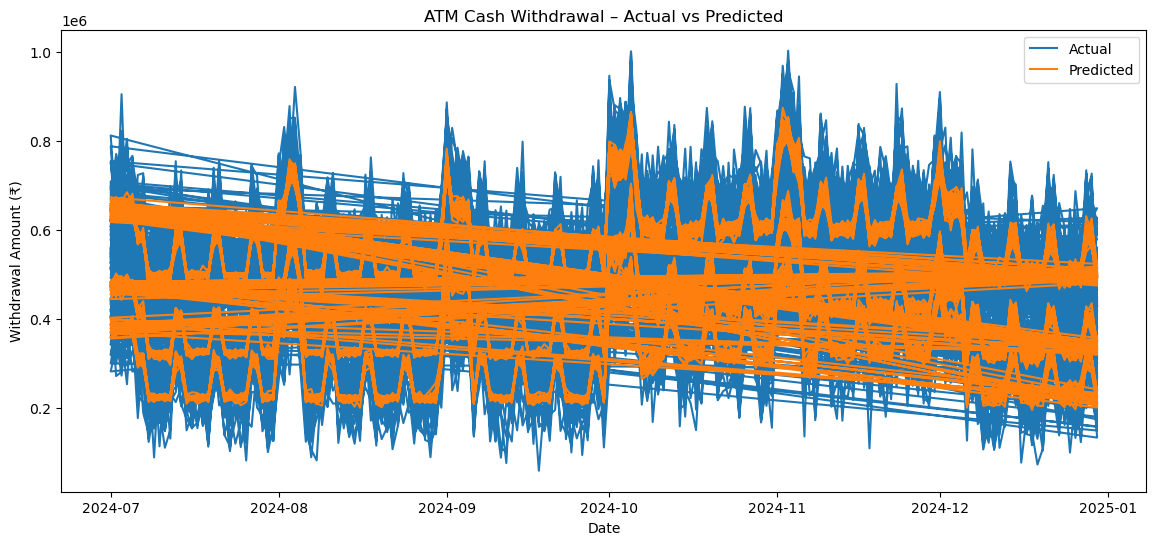

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(results["date"], results["actual"], label="Actual")
plt.plot(results["date"], results["predicted"], label="Predicted")
plt.title("ATM Cash Withdrawal – Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Withdrawal Amount (₹)")
plt.legend()
plt.show()


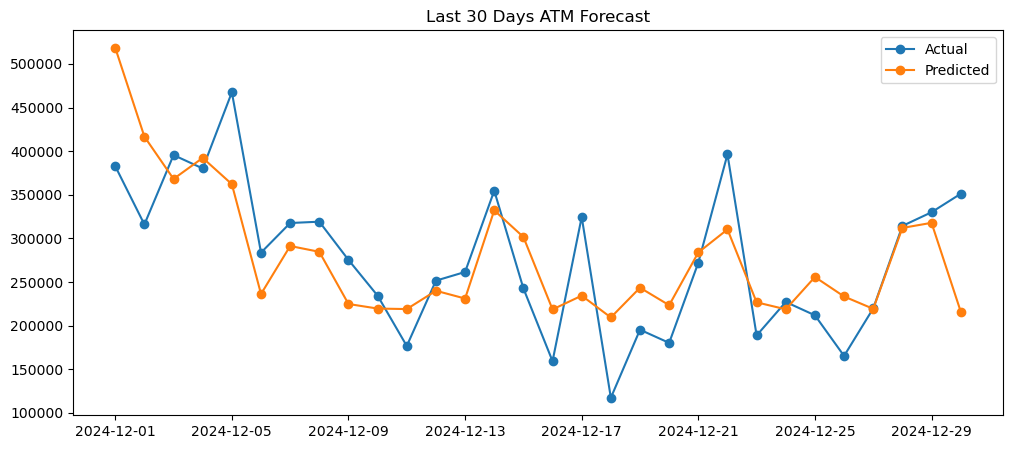

In [20]:
last_30 = results.tail(30)

plt.figure(figsize=(12, 5))
plt.plot(last_30["date"], last_30["actual"], marker="o", label="Actual")
plt.plot(last_30["date"], last_30["predicted"], marker="o", label="Predicted")
plt.title("Last 30 Days ATM Forecast")
plt.legend()
plt.show()


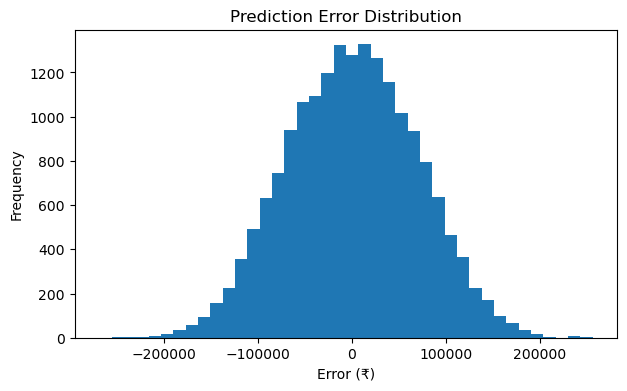

In [21]:
errors = results["actual"] - results["predicted"]

plt.figure(figsize=(7, 4))
plt.hist(errors, bins=40)
plt.title("Prediction Error Distribution")
plt.xlabel("Error (₹)")
plt.ylabel("Frequency")
plt.show()
